# BZ Reaction

This notebook contains the Belousov-Zhabotinsky (BZ) reaction experiments used in the paper. It includes the noisy analysis, the noise-free analysis, and the persistence diagrams for selected parameter values.

### Block 1 — Complete definitions

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
import pandas as pd
import os

# ============================================================
# 1. RK4 integrator
# ============================================================

def rk4_step(f, y, t, dt):
    k1 = np.asarray(f(y, t))
    k2 = np.asarray(f(y + dt/2 * k1, t + dt/2))
    k3 = np.asarray(f(y + dt/2 * k2, t + dt/2))
    k4 = np.asarray(f(y + dt * k3, t + dt))
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def rk4_integrate(f, y0, t):
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    dt = t[1] - t[0]
    for i in range(1, len(t)):
        y[i] = rk4_step(f, y[i-1], t[i-1], dt)
    return y

# ============================================================
# 2. 2D BZ simulator
# ============================================================

def simulate_bz(
    b,
    a=10.0,
    T=100.0,
    dt=0.01,
    SampleSize=4000,
    InitialConditions=None
):
    if InitialConditions is None:
        InitialConditions = [2.0, 5.01]

    t = np.arange(0, T, dt)

    def bz_2d(state, t):
        x, y = state
        dxdt = a - x - (4 * x * y) / (1 + x**2)
        dydt = b * x * (1 - y / (1 + x**2))
        return dxdt, dydt

    states = rk4_integrate(bz_2d, InitialConditions, t)

    ts = [
        states[:, 0][-SampleSize:],
        states[:, 1][-SampleSize:]
    ]
    t = t[-SampleSize:]

    return t, ts

# ============================================================
# 3. Plot style
# ============================================================

REF_COLOR   = "#2F5D8A"   # dark blue
CHG_COLOR   = "#7A1F1F"   # dark red
GREEN_DARK  = "#1F5A3A"   # dark green
DIAG_COLOR  = "#111111"
GRID_COLOR  = "#C8C8C8"
BG_COLOR    = "#FFFFFF"

NOISE_COLORS = {
    0.00: CHG_COLOR,
    0.02: REF_COLOR,
    0.04: GREEN_DARK,
    0.06: "#5B4B8A"
}

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": "white",
})

def style_2d_axes(ax):
    ax.grid(True, alpha=0.22, color=GRID_COLOR, linewidth=0.7)

    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.5)

    ax.tick_params(
        axis="both",
        which="major",
        length=3,
        width=0.8,
        color="black",
        labelcolor="black"
    )

    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

# ============================================================
# 4. Optional noise
# ============================================================

def add_noise(ts, noise_level=0.1, mode="relative", seed=None):
    if seed is not None:
        np.random.seed(seed)

    ts = np.asarray(ts)

    if mode == "relative":
        scale = noise_level * np.std(ts, axis=-1, keepdims=True)
    else:
        scale = noise_level

    noise = scale * np.random.randn(*ts.shape)
    return ts + noise

# ============================================================
# 5. Takens embedding
# ============================================================

def getTakensEmbedding(x, dim, Tau, dT=5):
    embedder = SingleTakensEmbedding(
        parameters_type="fixed",
        time_delay=Tau,
        dimension=dim,
        stride=dT,
        n_jobs=2
    )
    return embedder.fit_transform(x)

# ============================================================
# 6. Time-series generation
# ============================================================

def generate_bz_series(
    b,
    a=10.0,
    noise_level=0.0,
    sample_size=4000,
    fs=90,
    T=100.0
):
    # we use fs=90 as in the reported topological implementation
    dt = 1.0 / fs

    _, ts = simulate_bz(
        b=b,
        a=a,
        T=T,
        dt=dt,
        SampleSize=sample_size,
        InitialConditions=[2.0, 5.01]
    )

    ts = add_noise(ts, noise_level=noise_level, mode="relative", seed=42)

    # we take x(t)
    return np.asarray(ts[0]).ravel()

# ============================================================
# 7. Topology: max persistence + Betti L1
# ============================================================

def compute_topological_functionals_and_diagram(point_cloud, max_edge=40, n_samples=100):
    VR = VietorisRipsPersistence(
        homology_dimensions=[1],
        metric="manhattan",
        max_edge_length=max_edge
    )

    diagrams = VR.fit_transform(point_cloud[None, :, :])
    diag_H1 = diagrams[0][:, :2]

    diag_H1 = diag_H1[np.isfinite(diag_H1[:, 1])]

    if diag_H1.shape[0] == 0:
        max_persistence = 0.0
        betti_l1 = 0.0
    else:
        persistences = diag_H1[:, 1] - diag_H1[:, 0]
        max_persistence = np.max(persistences)

        P = np.linspace(0, max_edge, n_samples)
        betti_1 = np.zeros(n_samples)

        for i, e in enumerate(P):
            betti_1[i] = np.sum((diag_H1[:, 0] <= e) & (e < diag_H1[:, 1]))

        betti_l1 = np.sum(betti_1)

    return max_persistence, betti_l1, diag_H1

# ============================================================
# 8. Parámetros globales
# ============================================================

a = 10.0
b_critico = 3.5

dim = 2
tau = 57
dT = 5
max_edge = 40
n_betti_samples = 100

noise_levels = [0.00, 0.02, 0.04, 0.06]

# ============================================================
# 9. Topología for un b
# ============================================================

def compute_topology_for_b(
    b,
    noise_level,
    dim=dim,
    Tau=tau,
    dT=dT,
    max_edge=max_edge,
    n_samples=n_betti_samples
):
    serie_x = generate_bz_series(
        b=b,
        a=a,
        noise_level=noise_level,
        sample_size=4000,
        fs=90,
        T=100.0
    )

    embedding = getTakensEmbedding(serie_x, dim=dim, Tau=Tau, dT=dT)

    max_persistence, betti_l1, diag_H1 = compute_topological_functionals_and_diagram(
        embedding,
        max_edge=max_edge,
        n_samples=n_samples
    )

    return max_persistence, betti_l1, diag_H1

### Block 3 — Plots and export

In [7]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*force_all_finite.*",
    category=FutureWarning
)

## Additional noise-free analysis

- Block 1 — Complete definitions
- Block 2 — Single precomputation
- Block 3 — Noise-free plots
- Block 4 — Persistence diagrams for b = 3 and b = 4

### Block 1 — Complete definitions

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
import pandas as pd
import os

# ============================================================
# 1. RK4 integrator
# ============================================================

def rk4_step(f, y, t, dt):
    k1 = np.asarray(f(y, t))
    k2 = np.asarray(f(y + dt/2 * k1, t + dt/2))
    k3 = np.asarray(f(y + dt/2 * k2, t + dt/2))
    k4 = np.asarray(f(y + dt * k3, t + dt))
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def rk4_integrate(f, y0, t):
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    dt = t[1] - t[0]
    for i in range(1, len(t)):
        y[i] = rk4_step(f, y[i-1], t[i-1], dt)
    return y

# ============================================================
# 2. 2D BZ simulator
# ============================================================

def simulate_bz(
    b,
    a=10.0,
    L=100.0,
    fs=90,
    SampleSize=4000,
    InitialConditions=None
):
    if InitialConditions is None:
        InitialConditions = [2.0, 5.01]

    t = np.linspace(0, L, int(L * fs))

    def bz_2d(state, t):
        x, y = state
        dxdt = a - x - (4 * x * y) / (1 + x**2)
        dydt = b * x * (1 - y / (1 + x**2))
        return dxdt, dydt

    states = rk4_integrate(bz_2d, InitialConditions, t)

    ts = [
        states[:, 0][-SampleSize:],
        states[:, 1][-SampleSize:]
    ]
    t = t[-SampleSize:]

    return t, ts

# ============================================================
# 3. Plot style
# ============================================================

REF_COLOR = "#1F3FFF"   # dark blue
CHG_COLOR = "#D62728"   # dark red
DIAG_COLOR = "#000000"
GRID_COLOR = "#C8C8C8"
BG_COLOR   = "#FFFFFF"

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": "white",
})

def style_2d_axes(ax):
    ax.grid(True, alpha=0.22, color=GRID_COLOR, linewidth=0.7)

    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.5)

    ax.tick_params(
        axis="both",
        which="major",
        length=3,
        width=0.8,
        color="black",
        labelcolor="black"
    )

    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

# ============================================================
# 4. Optional noise
# ============================================================

ruido = 0.00

def add_noise(ts, noise_level=0.1, mode="relative", seed=None):
    if seed is not None:
        np.random.seed(seed)

    ts = np.asarray(ts)

    if mode == "relative":
        scale = noise_level * np.std(ts, axis=-1, keepdims=True)
    else:
        scale = noise_level

    noise = scale * np.random.randn(*ts.shape)
    return ts + noise

# ============================================================
# 5. Takens embedding
# ============================================================

def getTakensEmbedding(x, dim, Tau, dT=5):
    embedder = SingleTakensEmbedding(
        parameters_type="fixed",
        time_delay=Tau,
        dimension=dim,
        stride=dT,
        n_jobs=2
    )
    return embedder.fit_transform(x)

# ============================================================
# 6. Time-series generation
# ============================================================

def generate_bz_series(b, sample_size=4000, fs=90):
    _, ts = simulate_bz(
        b=b,
        a=10.0,
        L=100.0,
        fs=fs,
        SampleSize=sample_size,
        InitialConditions=[2.0, 5.01]
    )

    ts = add_noise(ts, noise_level=ruido, mode="relative", seed=42)
    return np.asarray(ts[0]).ravel()

# ============================================================
# 7. Topology: max persistence + Betti L1
# ============================================================

def compute_topological_functionals_and_diagram(point_cloud, max_edge=40, n_samples=100):
    VR = VietorisRipsPersistence(
        homology_dimensions=[1],
        metric="manhattan",
        max_edge_length=max_edge
    )

    diagrams = VR.fit_transform(point_cloud[None, :, :])
    diag_H1 = diagrams[0][:, :2]

    # quitar muertes infinitas
    diag_H1 = diag_H1[np.isfinite(diag_H1[:, 1])]

    # max persistence
    if diag_H1.shape[0] == 0:
        max_persistence = 0.0
    else:
        persistences = diag_H1[:, 1] - diag_H1[:, 0]
        max_persistence = np.max(persistences)

    # Betti-1 L1
    P = np.linspace(0, max_edge, n_samples)
    betti_1 = np.zeros(n_samples)

    for i, e in enumerate(P):
        betti_1[i] = np.sum((diag_H1[:, 0] <= e) & (e < diag_H1[:, 1]))

    betti_l1 = np.sum(betti_1)

    return max_persistence, betti_l1, diag_H1

# ============================================================
# 8. Parámetros globales
# ============================================================

a = 10.0
b_critico = 3.5

dim = 2
tau = 57
dT = 5
max_edge = 40
n_betti_samples = 100

# ============================================================
# 9. Topología for un b
# ============================================================

def compute_topology_for_b(b, dim=dim, Tau=tau, dT=dT, max_edge=max_edge, n_samples=n_betti_samples):
    serie_x = generate_bz_series(b)
    embedding = getTakensEmbedding(serie_x, dim=dim, Tau=Tau, dT=dT)

    max_persistence, betti_l1, diag_H1 = compute_topological_functionals_and_diagram(
        embedding,
        max_edge=max_edge,
        n_samples=n_samples
    )

    return max_persistence, betti_l1, diag_H1

### Block 2 — Single precomputation

In [53]:
def precompute_bz_topology(b_values, dim=dim, Tau=tau, dT=dT, max_edge=max_edge, n_samples=n_betti_samples):
    H1_diagrams = {}
    max_persistence_values = {}
    betti_l1_values = {}

    for i, b in enumerate(b_values):
        mp, bl1, diag_H1 = compute_topology_for_b(
            b=b,
            dim=dim,
            Tau=Tau,
            dT=dT,
            max_edge=max_edge,
            n_samples=n_samples
        )

        H1_diagrams[b] = diag_H1
        max_persistence_values[b] = mp
        betti_l1_values[b] = bl1

        # print(f"b = {b:.5f} -> max persistence = {mp:.6f}, ||Bv_1||_1 = {bl1:.3f} ({i+1}/{len(b_values)})")

    return H1_diagrams, max_persistence_values, betti_l1_values


# ============================================================
# RUNNING THE PRECOMPUTATION
# ============================================================

b_values = np.round(np.linspace(2, 5, 300), 3)

H1_diagrams, max_persistence_values, betti_l1_values = precompute_bz_topology(
    b_values,
    dim=dim,
    Tau=tau,
    dT=dT,
    max_edge=max_edge,
    n_samples=n_betti_samples
)

### Block 3 — Noise-free plots

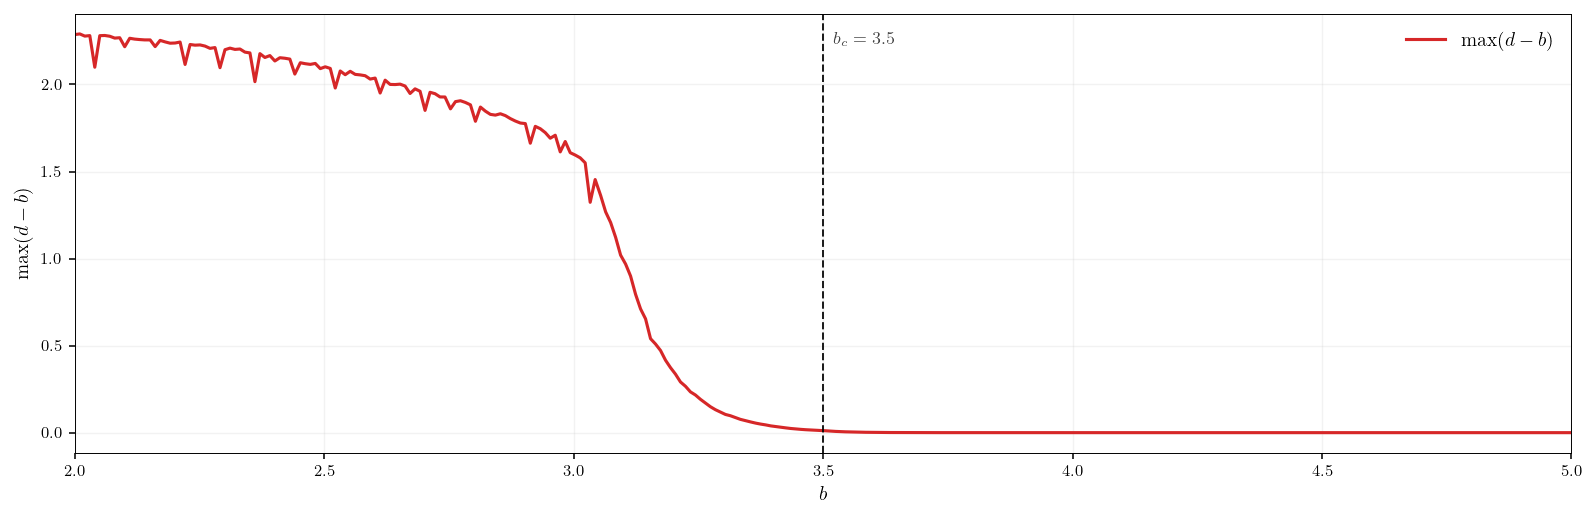


Archivo Excel guardado en:
outputs_bz_max_persistence/bz_max_persistence_b_2_5_n300_Tau57_m2_noise_0.0.xlsx



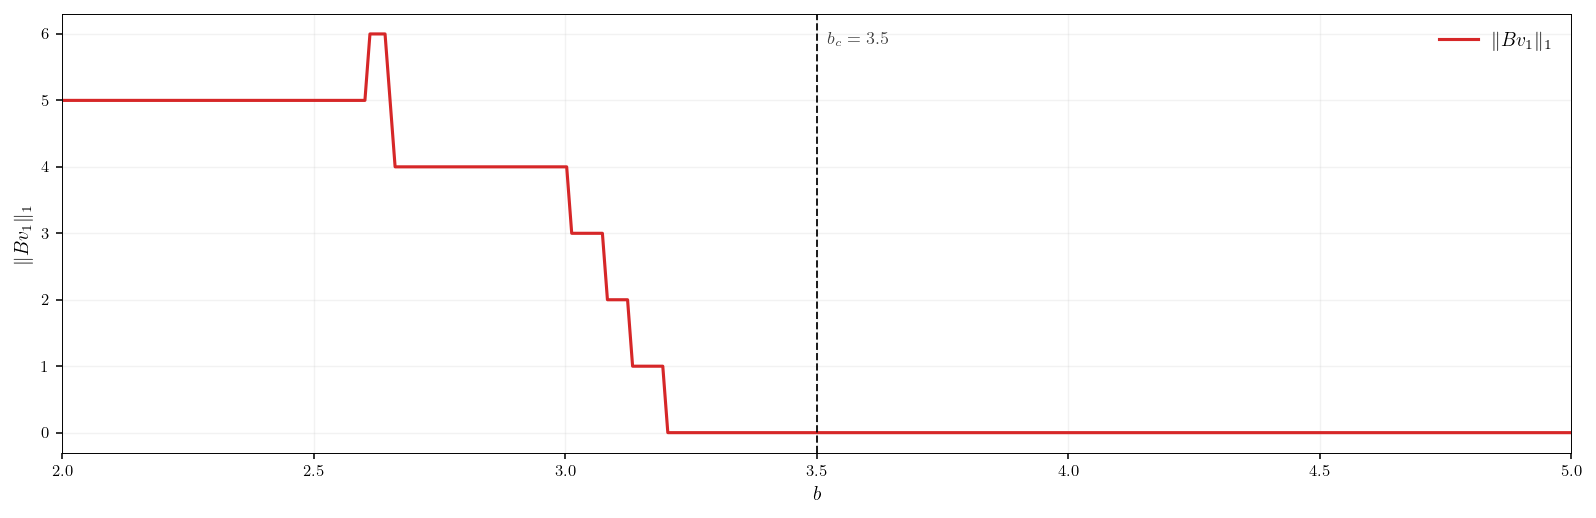


Archivo Excel guardado en:
outputs_bz_betti1_l1/bz_betti1_l1_b_2_5_n300_Tau57_m2_noise_0.0.xlsx



In [54]:
# ============================================================
# 1. Max persistence plot
# ============================================================

def plot_max_persistence_bz(b_values, max_persistence_values, save_excel=True):
    b_vals = list(b_values)
    mp_vals = [max_persistence_values[b] for b in b_vals]

    fig, ax = plt.subplots(figsize=(11.5, 3.8))

    ax.plot(
        b_vals,
        mp_vals,
        color=CHG_COLOR,
        lw=1.6,
        label=r"$\max(d-b)$"
    )

    ax.axvline(
        b_critico,
        color=DIAG_COLOR,
        linestyle="--",
        linewidth=1.0,
        alpha=0.9
    )

    ax.text(
        b_critico + 0.02, 0.96,
        rf"$b_c = {b_critico}$",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top",
        fontsize=9,
        color="#444444"
    )

    ax.set_xlim(2, 5)
    ax.set_xticks(np.arange(2, 5.01, 0.5))
    ax.margins(x=0.01)

    ax.set_xlabel(r"$b$")
    ax.set_ylabel(r"$\max(d-b)$")

    style_2d_axes(ax)
    ax.legend(frameon=False, loc="upper right")

    fig.tight_layout()
    fig.savefig("figure_bz_max_persistence.png", bbox_inches="tight")
    fig.savefig("figure_bz_max_persistence.pdf", bbox_inches="tight")
    plt.show()

    if save_excel:
        carpeta = "outputs_bz_max_persistence"
        os.makedirs(carpeta, exist_ok=True)

        archivo_excel = os.path.join(
            carpeta,
            f"bz_max_persistence_b_2_5_n{len(b_values)}_Tau{tau}_m{dim}_noise_{ruido}.xlsx"
        )

        df = pd.DataFrame({
            "b": b_vals,
            "max_persistence_H1": mp_vals
        })
        df.to_excel(archivo_excel, index=False)
        print(f"\nArchivo Excel guardado en:\n{archivo_excel}\n")


# ============================================================
# 2. Betti L1 plot
# ============================================================

def plot_betti_l1_bz(b_values, betti_l1_values, save_excel=True):
    b_vals = list(b_values)
    bl1_vals = [betti_l1_values[b] for b in b_vals]

    fig, ax = plt.subplots(figsize=(11.5, 3.8))

    ax.plot(
        b_vals,
        bl1_vals,
        color=CHG_COLOR,
        lw=1.6,
        label=r"$\|Bv_1\|_1$"
    )

    ax.axvline(
        b_critico,
        color=DIAG_COLOR,
        linestyle="--",
        linewidth=1.0,
        alpha=0.9
    )

    ax.text(
        b_critico + 0.02, 0.96,
        rf"$b_c = {b_critico}$",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top",
        fontsize=9,
        color="#444444"
    )

    ax.set_xlim(2, 5)
    ax.set_xticks(np.arange(2, 5.01, 0.5))
    ax.margins(x=0.01)

    ax.set_xlabel(r"$b$")
    ax.set_ylabel(r"$\|Bv_1\|_1$")

    style_2d_axes(ax)
    ax.legend(frameon=False, loc="upper right")

    fig.tight_layout()
    fig.savefig("figure_bz_betti1_l1.png", bbox_inches="tight")
    fig.savefig("figure_bz_betti1_l1.pdf", bbox_inches="tight")
    plt.show()

    if save_excel:
        carpeta = "outputs_bz_betti1_l1"
        os.makedirs(carpeta, exist_ok=True)

        archivo_excel = os.path.join(
            carpeta,
            f"bz_betti1_l1_b_2_5_n{len(b_values)}_Tau{tau}_m{dim}_noise_{ruido}.xlsx"
        )

        df = pd.DataFrame({
            "b": b_vals,
            "L1_norm_Bv1": bl1_vals
        })
        df.to_excel(archivo_excel, index=False)
        print(f"\nArchivo Excel guardado en:\n{archivo_excel}\n")


# ============================================================
# 3. RUNNING THE PLOTS
# ============================================================

plot_max_persistence_bz(
    b_values,
    max_persistence_values,
    save_excel=True
)

plot_betti_l1_bz(
    b_values,
    betti_l1_values,
    save_excel=True
)

### Block 4 — Persistence diagrams for 

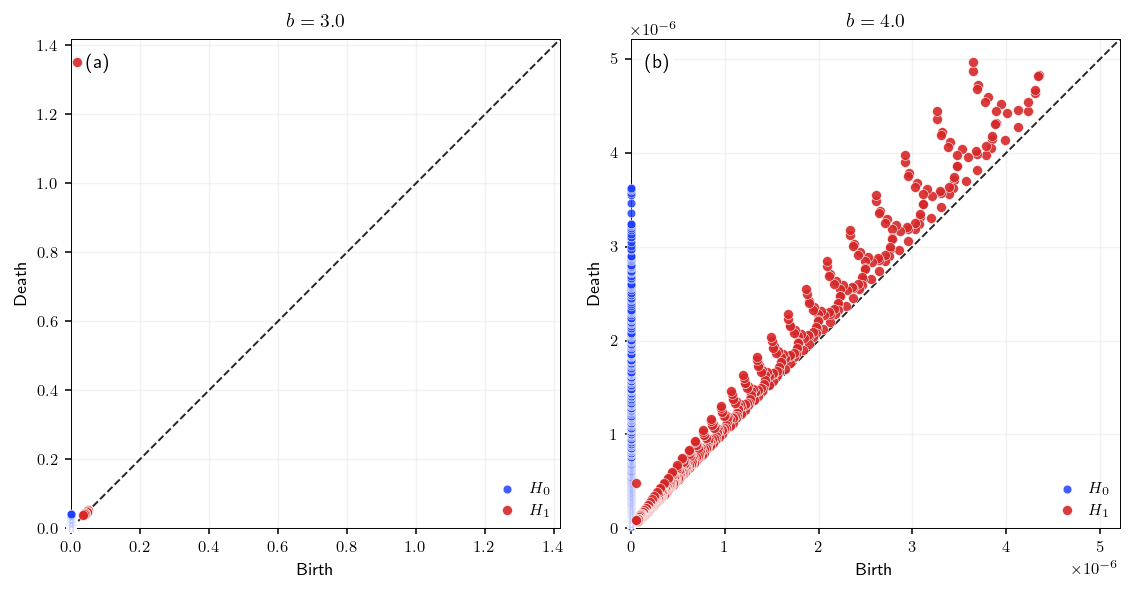

Saved files:
 - figure_bz_persistence_b3_b4.png
 - figure_bz_persistence_b3_b4.pdf


In [55]:
############################################################
#   PERSISTENCE DIAGRAMS FOR BZ: b = 3 and b = 4       #
#   using custom RK4, with axes starting at 0 and legends in both panels #
############################################################

import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import SingleTakensEmbedding
from ripser import ripser

# ============================================================
# 1. RK4 integrator
# ============================================================

def rk4_step(f, y, t, dt):
    k1 = np.asarray(f(y, t))
    k2 = np.asarray(f(y + dt/2 * k1, t + dt/2))
    k3 = np.asarray(f(y + dt/2 * k2, t + dt/2))
    k4 = np.asarray(f(y + dt * k3, t + dt))
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def rk4_integrate(f, y0, t):
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    dt = t[1] - t[0]
    for i in range(1, len(t)):
        y[i] = rk4_step(f, y[i-1], t[i-1], dt)
    return y

# ============================================================
# 2. BZ simulator
# ============================================================

def simulate_bz(b, a=10.0, L=100.0, fs=90, SampleSize=4000, InitialConditions=None):
    if InitialConditions is None:
        InitialConditions = [2.0, 5.01]

    t = np.linspace(0, L, int(L * fs))

    def bz_2d(state, t):
        x, y = state
        dxdt = a - x - (4 * x * y) / (1 + x**2)
        dydt = b * x * (1 - y / (1 + x**2))
        return dxdt, dydt

    states = rk4_integrate(bz_2d, InitialConditions, t)

    ts = [
        states[:, 0][-SampleSize:],
        states[:, 1][-SampleSize:]
    ]
    t = t[-SampleSize:]

    return t, ts

# ============================================================
# 3. Global style
# ============================================================

REF_COLOR = "#1F3FFF"
CHG_COLOR = "#D62728"
DIAG_COLOR = "#000000"
GRID_COLOR = "#C8C8C8"
BG_COLOR   = "#FFFFFF"

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": "white",
})

def style_2d_axes(ax):
    ax.grid(True, alpha=0.22, color=GRID_COLOR, linewidth=0.7)

    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.5)

    ax.tick_params(
        axis="both",
        which="major",
        length=3,
        width=0.8,
        color="black",
        labelcolor="black"
    )

    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

# ============================================================
# 4. Optional noise
# ============================================================

def add_noise(ts, noise_level=0.1, mode="relative", seed=None):
    if seed is not None:
        np.random.seed(seed)

    ts = np.asarray(ts)

    if mode == "relative":
        scale = noise_level * np.std(ts, axis=-1, keepdims=True)
    else:
        scale = noise_level

    noise = scale * np.random.randn(*ts.shape)
    return ts + noise

# ============================================================
# 5. Plotting helper
# ============================================================

panel_labels = ["a", "b"]

def plot_persistence_panel(ax, dgms, b_value, panel_label):
    h0 = dgms[0]
    h1 = dgms[1] if len(dgms) > 1 else np.empty((0, 2))

    h0 = h0[~np.isinf(h0[:, 1])] if len(h0) > 0 else h0
    h1 = h1[~np.isinf(h1[:, 1])] if len(h1) > 0 else h1

    finite_parts = []
    if len(h0) > 0:
        finite_parts.append(h0)
    if len(h1) > 0:
        finite_parts.append(h1)

    if len(finite_parts) == 0:
        ax.set_title(rf"$b = {b_value}$", pad=6)
        ax.set_xlabel("Birth")
        ax.set_ylabel("Death")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        style_2d_axes(ax)
        ax.text(
            0.03, 0.97, f"({panel_label})",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.16", facecolor="white", edgecolor="none", alpha=0.92)
        )
        return

    all_pts = np.vstack(finite_parts)

    if len(h0) > 0:
        ax.scatter(
            h0[:, 0], h0[:, 1],
            s=20, color=REF_COLOR, alpha=0.85,
            edgecolors="white", linewidths=0.30,
            label=r"$H_0$",
            zorder=3,
            clip_on=False
        )

    if len(h1) > 0:
        ax.scatter(
            h1[:, 0], h1[:, 1],
            s=26, color=CHG_COLOR, alpha=0.90,
            edgecolors="white", linewidths=0.30,
            label=r"$H_1$",
            zorder=3,
            clip_on=False
        )

    max_val = float(np.max(all_pts))
    if max_val <= 0:
        max_val = 1.0

    pad = 0.05 * max_val
    upper = max_val + pad

    ax.plot(
        [0, upper], [0, upper],
        linestyle="--", linewidth=1.0,
        color=DIAG_COLOR, alpha=0.85,
        zorder=2
    )

    ax.set_xlim(0, upper)
    ax.set_ylim(0, upper)
    ax.set_aspect("equal", adjustable="box")
    ax.margins(x=0.03, y=0.03)

    ax.set_title(rf"$b = {b_value}$", pad=6)
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    style_2d_axes(ax)

    ax.legend(
        frameon=False,
        loc="lower right",
        fontsize=8,
        handletextpad=0.4,
        borderpad=0.2
    )

    ax.text(
        0.03, 0.97, f"({panel_label})",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10, fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.16",
            facecolor="white",
            edgecolor="none",
            alpha=0.92
        )
    )

# ============================================================
# 6. Configuración
# ============================================================

b_values_diag = [3.0, 4.0]

embedding_dimension_2D = 2
embedding_time_delay_2D = 57
stride_2D = 5

embedder_ts_2D = SingleTakensEmbedding(
    parameters_type="fixed",
    time_delay=embedding_time_delay_2D,
    dimension=embedding_dimension_2D,
    stride=stride_2D,
    n_jobs=2
)

ruido = 0.0

# ============================================================
# 7. Figura 1x2
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(8.2, 4.2))
axs = np.atleast_1d(axs).ravel()

for i, b in enumerate(b_values_diag):

    t, ts = simulate_bz(
        b=b,
        a=10.0,
        L=100.0,
        fs=90,
        SampleSize=4000,
        InitialConditions=[2.0, 5.01]
    )

    ts = add_noise(ts, noise_level=ruido, mode="relative", seed=42)

    x_series = np.asarray(ts[0]).ravel()

    X_emb = embedder_ts_2D.fit_transform(x_series)
    dgms = ripser(X_emb, maxdim=1)["dgms"]

    plot_persistence_panel(axs[i], dgms, b, panel_labels[i])

fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig("figure_bz_persistence_b3_b4.png", bbox_inches="tight")
fig.savefig("figure_bz_persistence_b3_b4.pdf", bbox_inches="tight")

plt.show()

print("Saved files:")
print(" - figure_bz_persistence_b3_b4.png")
print(" - figure_bz_persistence_b3_b4.pdf")